<a href="https://colab.research.google.com/github/AndersStaxen/Class_Python_for_Policy/blob/main/session3_nltk_worksheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 📝 Python for Public Policy — Session 3 Worksheet  
**Theme:** Text Analysis with NLTK (Inaugural Speeches or Your Own `.txt`)

Use this notebook during the 60‑minute student-driven block. **No presentations** at the end.  
You may analyze an NLTK inaugural speech **or** upload your own plain text file (`.txt`).

**Timing guide:**  
- Part A: 10 min · Part B: 10 min · Part C: 10 min · Part D: 10 min · Part E: 10 min · Part F: 10 min



## Part 0 — Setup (run once)
Upgrade NLTK (Colab often pins an older version) and download the datasets we need.


In [ ]:

# We upgrade NLTK to the latest version so functions and data work as expected.
!pip -q install -U nltk

# Now we import nltk and download only the small packages we need for this session.
import nltk
needed = ["punkt_tab",           # tokenizer (splits text into words)
          "stopwords",       # list of common words to remove (the, and, is, ...)
          "wordnet",         # lexical database used for lemmatization (getting word roots)
          "averaged_perceptron_tagger_eng",  # part-of-speech tagger (N/V/Adj/Adv)
          "inaugural"]       # a small corpus of U.S. inaugural addresses
for pkg in needed:
    nltk.download(pkg, quiet=True) # no status text printed - just downloads

print("NLTK version:", nltk.__version__)


NLTK version: 3.9.2



## Part A — Pick Your Text (10 min)
Choose **one** source below.

### Option 1 — Use the built-in Inaugural Speeches corpus


In [ ]:

from nltk.corpus import inaugural
fileids = inaugural.fileids()
fileids[:10]  # preview a few
# Choose one speech (change the index or pick a specific filename from 'fileids')
s1 = fileids[-5]
raw = inaugural.raw(s1)
print("Analyzing:", s1, "| characters:", len(raw))


Analyzing: 2009-Obama.txt | characters: 13439



### Option 2 — Upload your own `.txt`
> Must be **plain text** (e.g., speech, policy memo, report). If you upload multiple files, we’ll read the first one.


If you don’t already have a `.txt` file (like the inaugural corpus examples), you can **make one directly in Colab**.  
This is helpful if you want to analyze text copied from a website, a PDF, or your own writing.

📝 Example: paste any text (such as a news article, policy speech, or blog post) into the triple quotes below.

In [ ]:

# Create a plain-text file in Colab
text = """Hello,
This is David Kelly, Chief Strategist here at J.P. Morgan Asset Management and I’d like to give you a
brief update on our views on the economic and market outlook using slides from our fourth quarter
Guide to the Markets – 10 points in 10 slides in 10 minutes:

The economy should slow down, speed up and then slow down again over the next year.
The collective impact of tariffs and tariff uncertainty, federal government cutbacks and declining
immigration, appear to be slowing the U.S. economy, although most of the negative effects should be
delayed until the fourth quarter. Looking past swings in imports and inventories, we expect real final
sales of domestic product to rise from 1.9% annualized growth in the first half of the year to 2.5% in
the third quarter, but then slide to less than 0.5% growth in the fourth.
However, passage of the OBBBA should inject stimulus into the economy early in 2026 via very strong
income tax refunds. This should boost economic activity in the first half of 2026. Thereafter, we
expect growth to slow again in the second half of 2026 as the refund effect fades and the effects of
higher tariffs and lower immigration linger.

Lower immigration should limit the increase unemployment caused by a slow economy.
A slower-growing U.S. economy will mean slower job growth, with average monthly payroll gains
potentially falling below 50,000 for the rest of 2025 before reaccelerating slightly in 2026. However,
the impact of this slow job growth on the unemployment rate should be suppressed by a sharp
decline in immigration.
Illegal immigration has fallen almost to zero and deportations have increased. Data through May also
suggested a decline in new immigrant visas issued. Data on both deportations and legal immigration
are very spotty but overall we believe that net immigration could fall to less than 250,000 per year,
down from an average of over 1,000,000 per year in the two decades before the pandemic. This
implies a flat or declining labor force, limiting the increase in the unemployment rate to just 4.5% by
the fourth quarter of this year and then holding at the level in early 2026.
We expect that wage growth will remain steady as recession worries counteract tight labor markets
in wage negotiations.

Inflation should rise over the next year due to tariffs and fiscal stimulus but fall later in 2026.
The impact of tariffs on inflation is beginning to be felt, with year-over-year CPI inflation rising to
2.9% in August. We believe that tariff impacts on inflation will increase in coming months as retailers
apply mark ups to new inventories.
By the fourth quarter, we expect inflation will have risen to 3.7%, year-over-year, according to the
consumer price index and about 3.4%, according to the personal consumption deflator which is the
Fed’s preferred measure. This inflation could be sustained into early 2026 due to the effect of higher
income tax refunds on consumer spending, with year-over-year inflation potentially peaking in the
second quarter of 2026. However, as the economy slows again in the second half of 2026, inflation
should gradually drift down towards the Fed’s 2% target.

The Fed may cut only once this year due to elevated inflation but could cut more in late 2026.
In September, the Federal Reserve resumed its easing cycle, cutting the federal funds rate by 0.25%
to a range of 4.00% to 4.25%. We expect them to cut twice more in the fourth quarter of this year
and deliver two further cuts in the first half of 2026.
In doing so, they will continue to point to slowing employment growth and assert that monetary
policy remains mildly restrictive since they regard the “neutral” rate of interest as being somewhere
close to 3.0%.
However, in implementing this gradual easing they may well be seen as caving to political pressure
since their own Summary of Economic Projections shows that, by the end of 2025, they expect the
inflation rate to be further above their 2% target than the unemployment rate will be relative to their
4.2% long-run expectation.
Once the federal funds rate has been cut to a range of 3.00%-3.25% we expect the Fed to go back on
hold until the economy sees some further serious economic weakness or inflation dips below 2.0%,
neither of which we anticipate before 2027.

Mega-cap U.S. equities still look expensive relative to the rest of the market.
One glaring anomaly, entering 2026, was the huge outperformance of the largest companies in the
S&P500, both in terms of earnings and equity market gains. Much of this reflects the dominant
market position of U.S. tech firms and a surge of interest in and investment spending on artificial
intelligence. That being said, in recent years, the stock market outperformance of these companies
has generally outpaced their outperformance in earnings, leaving their valuations at high levels
relative to the rest of the market.
Despite huge market volatility in the spring, this anomaly persists today with the top 10 companies in
the S&P500 representing roughly 40% of the market value of the entire index. For long-term
investors, it may make sense to increase allocations to other areas of financial markets in case,
economic, geopolitical or idiosyncratic forces turns a mega-cap U.S. equity boom into a bust.

Bond yields look close to fair value arguing for a neutral allocation.
A resumption of Fed easing and signs of a weaker labor market have allowed long-term interest rates
to drift down in recent months, even as inflation has gradually increased. From here, however, we
expect long-term rates to remain range-bound as the effects of a continued economic slowdown are
counteracted by increased Treasury issuance in the wake of the passage of the OBBBA and tariff-
related inflation.
For investors, there is not a strong argument for making a bet either on duration or credit in bonds.
Even if the economy weakens further, any rally in bonds should be limited by rising federal borrowing
and stubborn inflation. Moreover, at least in the short run, we expect the economy to avoid
recession, partially justifying today’s tight credit spreads. However, we do think that roughly normal
bond allocations make sense in this environment – historically, today’s close-to-4.3% yield on the
Bloomberg bond index has been associated with close to 4.3% annual returns over a 5-year period.
Provided inflation fades late next year, these yields and potential returns seem reasonable.

The dollar should drift down due to slow U.S. growth and portfolio rebalancing.
The dollar has fallen sharply since the start of the year. This may, in part, reflect its high valuation
going into the year and America’s chronic trade deficits. However, it could also be the result of
questions among both U.S. and international investors about their concentration in U.S. assets and
the policies of the new U.S. Administration.
A key driver of the dollar in the long run has been the higher interest rates offered on U.S. debt
compared to other DM economies. As the Federal Reserve cuts more aggressively than other central
banks in the months ahead we believe this narrowing in interest rate spreads, combined with a still
high trade deficit, should lead to a further dollar decline.

International equities still look cheap relative to the U.S. market.
So far in 2025, international stocks have sharply outperformed their U.S. counterparts, as local-
currency outperformance has been amplified by the impact of a falling dollar. Given this dramatic
outperformance, many investors may be wondering if they have missed the boat in increasing
international allocations.
We don’t believe so - for three reasons:
First, as we show in the chart, even after a 2025 rally, non-U.S. stocks still carry much lower
valuations than their U.S. counterparts.
Second, the dollar remains very over-valued given our trade fundamentals and we expect it to fall in
the years to come, and,
Third, given the outperformance of U.S. stocks over the last decade, most U.S. investors are likely
very underweight international stocks relative to an appropriate long-term asset allocation.

Alternative investments can provide total return, income and diversification.
The last few years have seen very strong stock market gains. However, that very outperformance
could limit future returns. Moreover, the traditional role that bonds play in zagging when stocks zig
has been challenged in recent years by higher inflation which negatively impacts both stocks and
bonds.
In this environment, many investors are exploring alternative assets, such as private equity, private
credit, infrastructure and real estate. These assets are all quite different – some provide strong long-
run returns, some generate strong current income and some act as good diversifiers to publicly-
traded stocks and bonds. Many of them are quite illiquid and so should be thought of only as long-
term investments and the performance of different assets within the alternatives space has varied
considerably depending on the manager. Still, adding alternatives to a traditional stock-bond
portfolio may make sense for many investors and we expect this area of financial markets to continue
to grow in the years ahead.

Portfolio drift may have left many investors overweight the most expensive assets.
Finally, it is to consider not just economic fundamentals and valuations but how investors are
positioned. The last five or six years, while filled with dramatic and difficult national and global
events, have also, on balance, seen very strong investment gains. However, these gains have been by
no means even, and, if investors have not been disciplined in rebalancing their portfolios, they have
not just grown in recent years – they have grown more risky. Indeed, as we show in the chart, a
portfolio which was 60% invested in stocks and 40% invested in bonds at the start of 2019, would
today have over a 70% allocation to stocks, assuming that dividends were reinvested in stocks and
coupons in bonds over the intervening years.
This may not be at all appropriate, given gains in wealth but also uncertainties in the outlook. For
many investors, as we enter the fourth quarter of 2025, it may make sense to gradually rebalance and
add diversification to a portfolio, particularly if this can be done in a tax-efficient manner."""

# Write the text into a .txt file
with open("mytext.txt", "w", encoding="utf-8") as f:
    f.write(text)

print("✅ Saved mytext.txt")

# Load your saved .txt file
with open("mytext.txt", encoding="utf-8") as f:
    raw = f.read()

print(raw[:500])  # print first 500 characters



✅ Saved mytext.txt
Hello,
This is David Kelly, Chief Strategist here at J.P. Morgan Asset Management and I’d like to give you a
brief update on our views on the economic and market outlook using slides from our fourth quarter
Guide to the Markets – 10 points in 10 slides in 10 minutes:

The economy should slow down, speed up and then slow down again over the next year.
The collective impact of tariffs and tariff uncertainty, federal government cutbacks and declining
immigration, appear to be slowing the U.S. econo



**Q:** Which text did you choose and why? *(Write a 1–2 sentence note below.)*


In [ ]:

# Your short reflection:
choice_note = """
The text is from a the quarterly markets update, held by JPM chief global markets strategist Dr. David Kelly. The speech covers the main takeaways of JPM's Quarterly 'Guide to the Markets'
"""
print(choice_note)



The text is from a the quarterly markets update, held by JPM chief global markets strategist Dr. David Kelly. The speech covers the main takeaways of JPM's Quarterly 'Guide to the Markets'




## Part B — Tokenize & Explore (10 min)
Lowercase and keep only alphabetic tokens (drop punctuation/numbers) for a quick clean view.


In [ ]:

from nltk.tokenize import word_tokenize

# Tokenize: split into tokens, lowercase them, keep alphabetic tokens only
tokens = [w.lower() for w in word_tokenize(raw) if w.isalpha()]
len(tokens), tokens[:20]


(1607,
 ['hello',
  'this',
  'is',
  'david',
  'kelly',
  'chief',
  'strategist',
  'here',
  'at',
  'morgan',
  'asset',
  'management',
  'and',
  'i',
  'd',
  'like',
  'to',
  'give',
  'you',
  'a'])


**Questions:**  
1) How many tokens (words) are in your text?  
2) List 5 tokens you expected to see. Were they present?



## Part C — Keyword in Context (10 min)
Use *concordance* to see your keywords in context.


In [ ]:

from nltk.text import Text
T = Text(tokens)

# Try two policy keywords of interest (edit these):
T.concordance("economy", width=70, lines=12)
T.concordance("inflation", width=70, lines=12)


Displaying 9 of 9 matches:
oints in slides in minutes the economy should slow down speed up and 
ation appear to be slowing the economy although most of the negative 
hould inject stimulus into the economy early in via very strong incom
 unemployment caused by a slow economy a economy will mean slower job
ent caused by a slow economy a economy will mean slower job growth wi
cond quarter of however as the economy slows again in the second half
d to go back on hold until the economy sees some further serious econ
or credit in bonds even if the economy weakens further any rally in b
in the short run we expect the economy to avoid recession partially j
Displaying 12 of 16 matches:
 markets in wage negotiations inflation should rise over the next yea
r in the impact of tariffs on inflation is beginning to be felt with 
beginning to be felt with cpi inflation rising to in august we believ
elieve that tariff impacts on inflation will increase in coming month
 the fourth quarter we expect infl


**Prompt:** In 2–3 sentences, what do the surrounding words suggest about how these topics are framed?


In [ ]:

analysis_notes = """
The main words surrounding the word 'economy' is 'slowing down' and 'weakens'.
The main words surrounding the word 'inflation' is 'rising' and 'delayed'.
"""
print(analysis_notes)



The main words surrounding the word 'economy' is 'slowing down' and 'weakens'.
The main words surrounding the word 'inflation' is 'rising' and 'delayed'.




## Part D — Dispersion Plot (10 min)
Where do topics appear (beginning/middle/end)? Replace terms with 3–5 of your own.


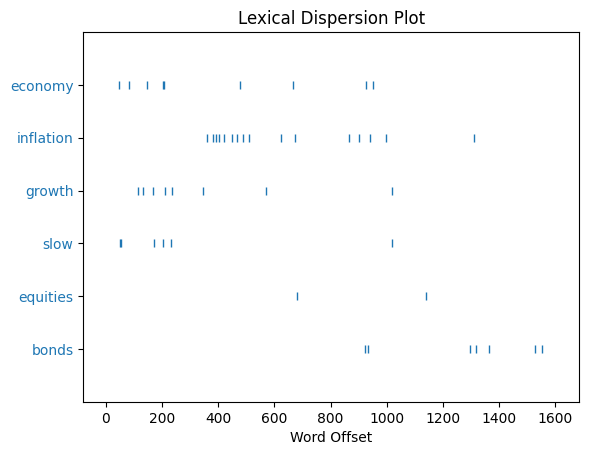

In [ ]:

# NLTK's dispersion_plot uses matplotlib under the hood
T.dispersion_plot(["economy", "inflation", "growth", "slow", "equities", "bonds"])



**Prompt:** What patterns do you notice? Why might this matter for policy framing?


In [ ]:

framing_notes = """
The context of the speech is '10 points, in 10 slides, in 10 min'. Knowing this, we see how some words were used only in relation to some slides
"""
print(framing_notes)



The context of the speech is '10 points, in 10 slides, in 10 min'. Knowing this, we see how some words were used only in relation to some slides




## Part E — Lexical Diversity (10 min)
Lexical diversity = unique words / total words. Use a fixed slice for fair comparisons.


In [ ]:

def lexical_diversity(tok_list, n=None):
    """Return unique/total; if n is provided, compute on first n tokens."""
    if n:
        tok_list = tok_list[:n]
    total = len(tok_list) if tok_list else 1
    return len(set(tok_list)) / total

div_all = lexical_diversity(tokens)
div_2k  = lexical_diversity(tokens, 2000)

print("Lexical diversity (all tokens):", round(div_all, 4))
print("Lexical diversity (first 2,000):", round(div_2k, 4))


Lexical diversity (all tokens): 0.3503
Lexical diversity (first 2,000): 0.3503



**Why it matters (policy analysis):** Differences in lexical diversity can reflect changes in audience targeting, technicality vs. accessibility, or agenda breadth (e.g., a narrow crisis speech vs. a broad programmatic agenda).  

*(Optional)* Compare with a second speech by repeating Part A for another `fileid` and recomputing diversity on the same slice size.



## Part F — Reflection (10 min)
- Which tool felt most useful for policy analysis (concordance, dispersion, lexical diversity)? Why?  
- How could you apply this to a real policy dataset (hearings, legislation, news, social media)?


In [ ]:

final_reflection = """
The concordance felt the most useful, as it provides context for the words used
"""
print(final_reflection)



The concordance felt the most useful, as it provides context for the words used




---
## 🚀 Stretch Challenges (Optional)

### 1) Collocations (common policy phrases)
Find frequently co-occurring word pairs (bigrams). These can reveal informative policy phrases (e.g., *national security*, *climate change*).


In [ ]:

from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder

# Use a filtered token list (already lowercase & alphabetic)
finder = BigramCollocationFinder.from_words(tokens)
# Only consider reasonably frequent bigrams (adjust min_freq to taste)
finder.apply_freq_filter(3)
bigrams_pmi = finder.nbest(BigramAssocMeasures.pmi, 15)
bigrams_pmi


[]


### 2) VADER sentiment on short snippets
Useful for very short statements (tweets, headlines). For long speeches, sentiment averages toward neutral.


In [ ]:

# VADER is in nltk.sentiment
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

samples = [
    "The economy should slow down, speed up and then slow down again over the next year.",
    "Lower immigration should limit the increase unemployment caused by a slow economy.",
    "Inflation should rise over the next year due to tariffs and fiscal stimulus but fall later in 2026.",
    "The Fed may cut only once this year due to elevated inflation but could cut more in late 2026.",
    "Mega-cap U.S. equities still look expensive relative to the rest of the market.",
    "Bond yields look close to fair value arguing for a neutral allocation.",
    "The dollar should drift down due to slow U.S. growth and portfolio rebalancing.",
    "International equities still look cheap relative to the U.S. market.",
    "Alternative investments can provide total return, income and diversification.",
    "Portfolio drift may have left many investors overweight the most expensive assets.",
]

for s in samples:
    print(s, "->", sia.polarity_scores(s))


The economy should slow down, speed up and then slow down again over the next year. -> {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Lower immigration should limit the increase unemployment caused by a slow economy. -> {'neg': 0.331, 'neu': 0.519, 'pos': 0.149, 'compound': -0.4215}
Inflation should rise over the next year due to tariffs and fiscal stimulus but fall later in 2026. -> {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
The Fed may cut only once this year due to elevated inflation but could cut more in late 2026. -> {'neg': 0.198, 'neu': 0.802, 'pos': 0.0, 'compound': -0.4939}
Mega-cap U.S. equities still look expensive relative to the rest of the market. -> {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Bond yields look close to fair value arguing for a neutral allocation. -> {'neg': 0.191, 'neu': 0.51, 'pos': 0.299, 'compound': 0.1779}
The dollar should drift down due to slow U.S. growth and portfolio rebalancing. -> {'neg': 0.0, 'neu': 0.822, 'pos': 0.

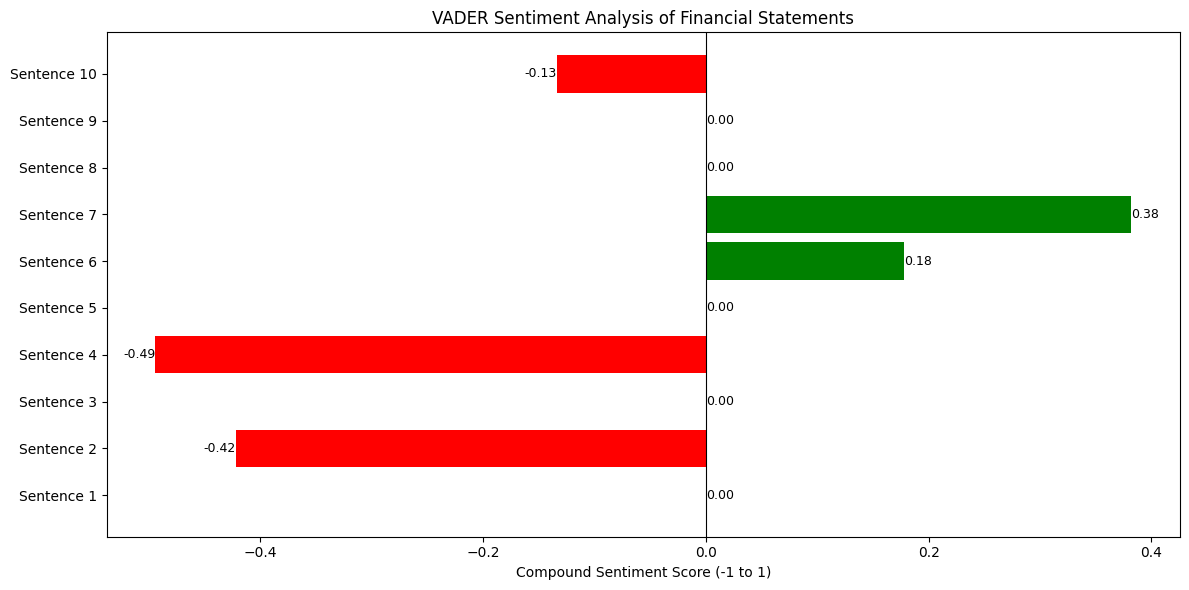

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data from the user's examples
sentences = [
    "The economy should slow down, speed up and then slow down again over the next year.",
    "Lower immigration should limit the increase unemployment caused by a slow economy.",
    "Inflation should rise over the next year due to tariffs and fiscal stimulus but fall later in 2026.",
    "The Fed may cut only once this year due to elevated inflation but could cut more in late 2026.",
    "Mega-cap U.S. equities still look expensive relative to the rest of the market.",
    "Bond yields look close to fair value arguing for a neutral allocation.",
    "The dollar should drift down due to slow U.S. growth and portfolio rebalancing.",
    "International equities still look cheap relative to the U.S. market.",
    "Alternative investments can provide total return, income and diversification.",
    "Portfolio drift may have left many investors overweight the most expensive assets."
]

results = [
    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0},
    {'neg': 0.331, 'neu': 0.519, 'pos': 0.149, 'compound': -0.4215},
    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0},
    {'neg': 0.198, 'neu': 0.802, 'pos': 0.0, 'compound': -0.4939},
    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0},
    {'neg': 0.191, 'neu': 0.51, 'pos': 0.299, 'compound': 0.1779},
    {'neg': 0.0, 'neu': 0.822, 'pos': 0.178, 'compound': 0.3818},
    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0},
    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0},
    {'neg': 0.173, 'neu': 0.691, 'pos': 0.137, 'compound': -0.1335}
]

# Convert to DataFrame
df = pd.DataFrame(results)
df["sentence"] = sentences

# Plot compound sentiment
plt.figure(figsize=(12,6))
bars = plt.barh(df.index, df["compound"], color=df["compound"].apply(lambda x: 'green' if x>0 else ('red' if x<0 else 'gray')))
plt.yticks(df.index, [f"Sentence {i+1}" for i in df.index])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Compound Sentiment Score (-1 to 1)")
plt.title("VADER Sentiment Analysis of Financial Statements")

# Add text labels
for bar, score in zip(bars, df["compound"]):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f"{score:.2f}", va='center',
             ha='left' if score>=0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()


### 3) Compare two texts (quick)
Repick another `fileid` and compute lexical diversity on the same slice (e.g., 2,000 tokens). What differences do you see?


In [ ]:

# Example scaffold:
# s2 = fileids[-1]
# raw2 = inaugural.raw(s2)
# tokens2 = [w.lower() for w in word_tokenize(raw2) if w.isalpha()]
# print("A:", s1, "div(2k) =", round(lexical_diversity(tokens, 2000), 4))
# print("B:", s2, "div(2k) =", round(lexical_diversity(tokens2, 2000), 4))



### 4) Quick frequency table + matplotlib bar chart
Show top 15 tokens (after simple cleaning). *Keep charts simple and readable.*


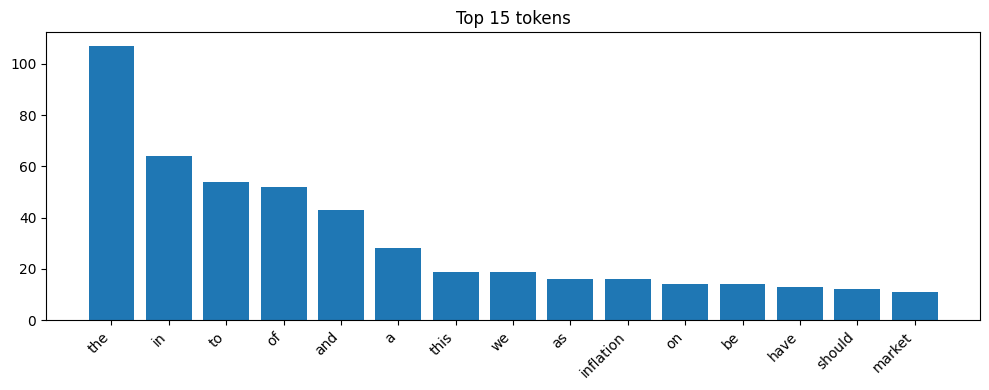

In [ ]:

from nltk import FreqDist
import matplotlib.pyplot as plt

fd = FreqDist(tokens)
top = fd.most_common(15)

labels, counts = zip(*top)
plt.figure(figsize=(10,4))
plt.bar(range(len(labels)), counts)
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.title("Top 15 tokens")
plt.tight_layout()
plt.show()
